In [1]:
import math

In [2]:
from math import*

In [3]:
import pandas as pd

In [4]:
import numpy as np

In [5]:
import matplotlib.pyplot as plt

In [6]:
def convert_to_matrix(subset_data):
    return subset_data.to_numpy()

In [7]:
def delta_p_df(df):
    return df.diff(axis=1).iloc[:, 1:]

In [8]:
def covariance_to_correlation(cov_matrix):
    variances = np.diag(cov_matrix)
    std_deviations = np.sqrt(variances)
    std_outer = np.outer(std_deviations, std_deviations)
    correlation_matrix = cov_matrix/std_outer
    return correlation_matrix

In [64]:
def plot_it(df, corr_matrix, main_labels, site_name):
    %matplotlib inline
    
    plt.figure(figsize=(10,6))

    new_list = []
    for s in range(len(main_labels)):
        new_list.append(main_labels[s:])
    print(new_list)

    rows_generation = [
            row.split('_')[1] for row in df.index
        ]
    
    for i in range(len(corr_matrix)-1):
        row_elements = corr_matrix[i,i+1:]
        labels = new_list[i]

        current_gen = rows_generation[i]
        
        plt.plot(labels, row_elements, marker='o', label=f'Generation{current_gen}')
        print('x-axis labels =', labels)

    plt.title('Correlation for site '+ site_name)
    plt.xlabel('Generation')
    plt.ylabel('Correlation Value')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
    return plt.show()

In [11]:
def subset_site_cols(dataframe, location):
    '''takes in dataframe as a table and a location number as a string and returns the subset'''
    cols_selected = [
        col for col in dataframe.columns
        if col == "1_0_1" or col.split("_")[0] == location
    ]
    subset_site = dataframe[cols_selected]
    return subset_site

In [12]:
def subset_dataframe(dataframe, location, replicate):
    '''takes in dataframe as table and a location and replicate number as a string and retruns subset of data'''
    cols_selected = [
        col for col in dataframe.columns
        if col == "1_0_1" or col.split("_")[0] == location and col.split("_")[-1] == replicate
    ]
    subset_dataframe = dataframe[cols_selected]
    return subset_dataframe

In [13]:
def subset_replicate(df, replicate):
    cols_selected = [
        col for col in df.columns
        if col == "1_0_1" or col.split("_")[-1] == replicate
    ]
    subset_df = df[cols_selected]
    return subset_df

In [29]:
extract_year = [
            col.split('_')[1] for col in subset_dataframe(master_df, '1', '2').columns
        ]
extract_year

['0', '1', '2', '4']

In [14]:
seedmix = pd.read_csv("seedmix_hapfire_allele_frequency_random_switch_fixrm.csv", nrows=10000)

In [15]:
master_df = pd.read_csv("PHASE_1_2_COMBINED_hapFIRE_allele_frequency_random_switch_fixrm.csv", nrows=10000)

In [16]:
master_df.insert(loc=0, column="1_0_1", value = seedmix["X3"])

In [17]:
def array_the_reps(master_matrix):
    return sorted(list(set(int(col.split('_')[2]) for col in master_matrix.columns)))

In [67]:
sites = sorted(list(set(int(col.split('_')[0]) for col in master_df.columns)))
sites

[1,
 2,
 4,
 5,
 6,
 9,
 10,
 11,
 12,
 13,
 23,
 24,
 25,
 26,
 27,
 28,
 32,
 33,
 37,
 42,
 43,
 45,
 46,
 48,
 49,
 52,
 53,
 54,
 55,
 57,
 60]

In [65]:
def find_the_plots_for_the_site(df, site):
    site_subset = subset_site_cols(df, site)
    reps = array_the_reps(site_subset)
    
    for r in reps:
        subset_df = subset_replicate(site_subset, str(r))
        subset_df_cov = delta_p_df(subset_df).cov()
        extract_year = [
            col.split('_')[1] for col in subset_df_cov.columns
        ]
        print(extract_year)
        correlation = covariance_to_correlation(subset_df_cov)
        plot_it(correlation, convert_to_matrix(correlation), extract_year[1:], site)
    return 

['1', '2', '3']
[['2', '3'], ['3']]
x-axis labels = ['2', '3']
x-axis labels = ['3']


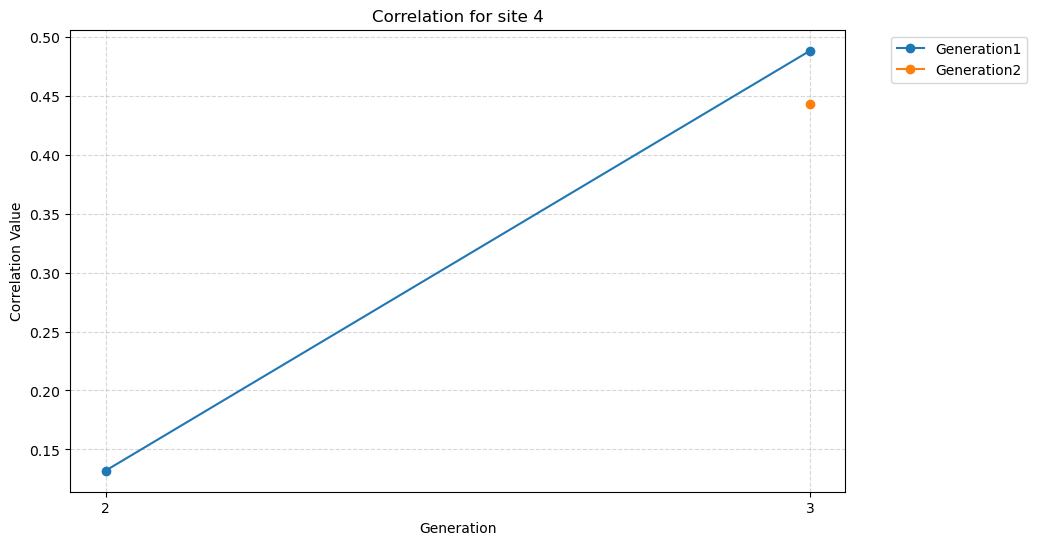

['1', '2', '3']
[['2', '3'], ['3']]
x-axis labels = ['2', '3']
x-axis labels = ['3']


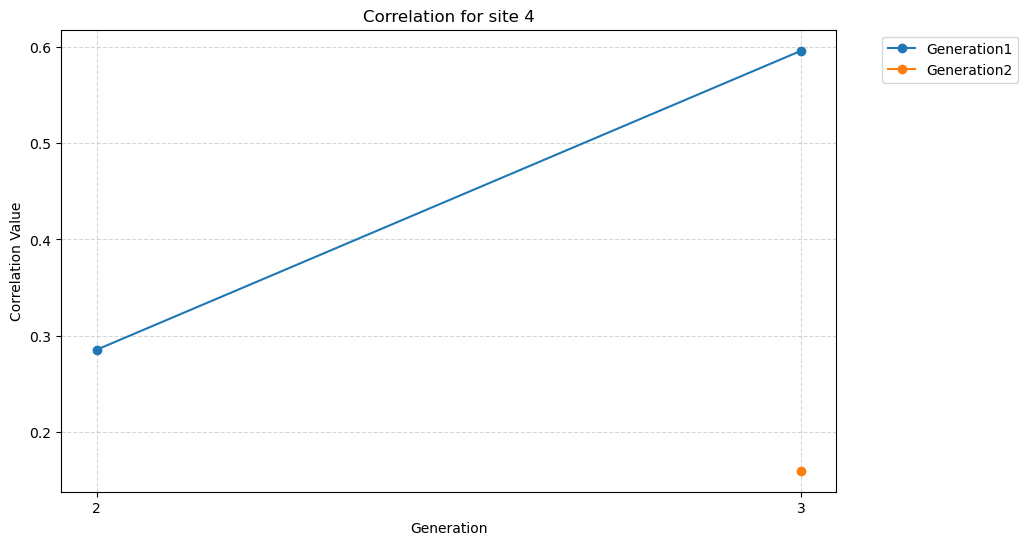

['1', '2', '3']
[['2', '3'], ['3']]
x-axis labels = ['2', '3']
x-axis labels = ['3']


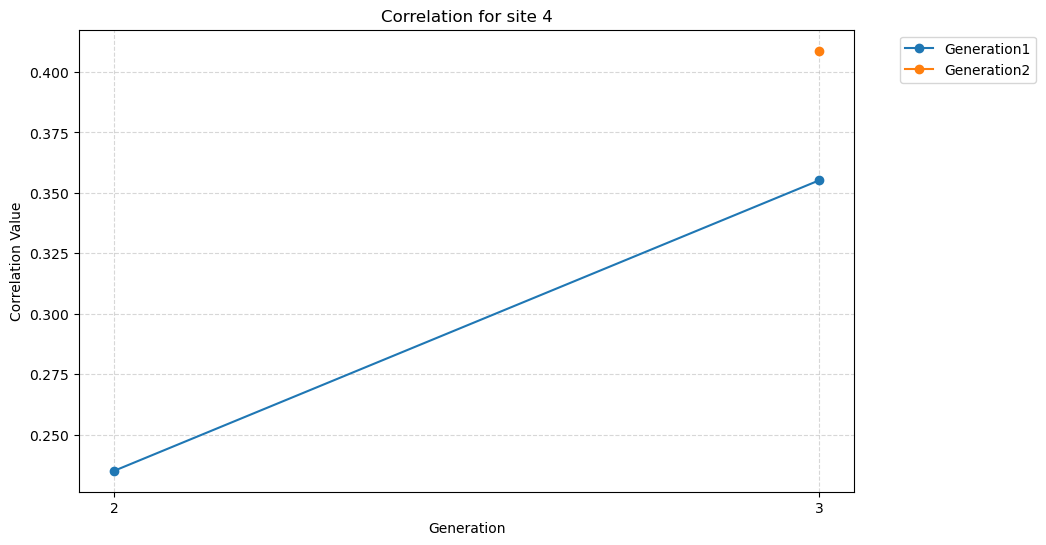

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


['1']
[]


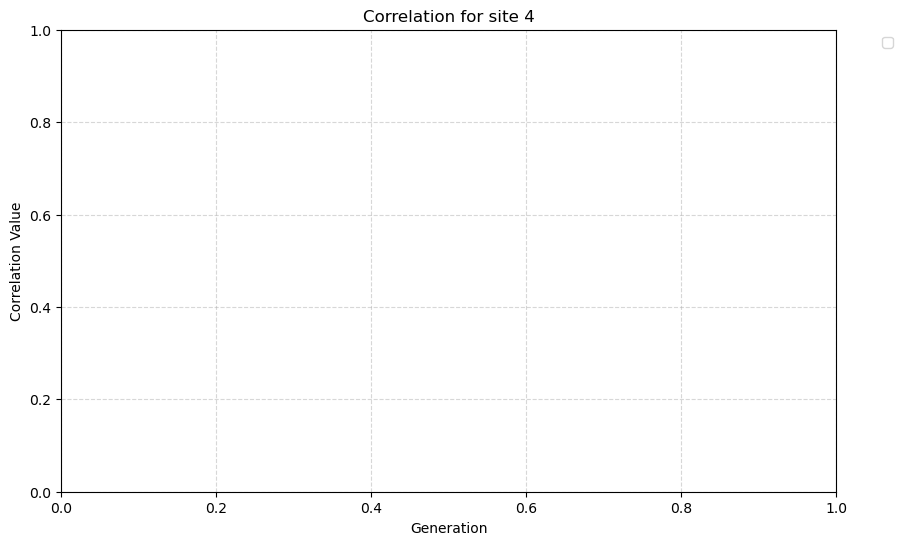

['1', '2', '3']
[['2', '3'], ['3']]
x-axis labels = ['2', '3']
x-axis labels = ['3']


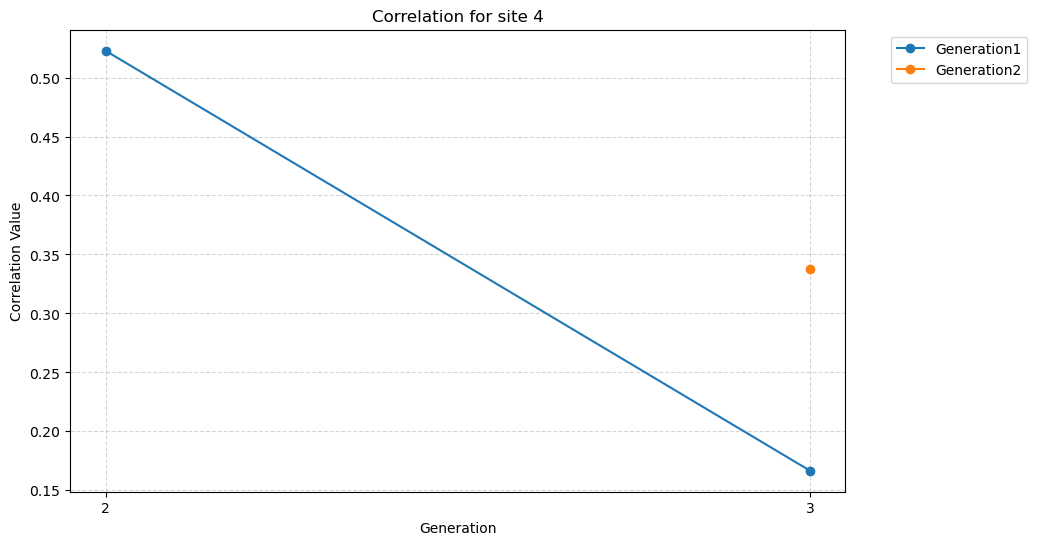

['1', '2', '3']
[['2', '3'], ['3']]
x-axis labels = ['2', '3']
x-axis labels = ['3']


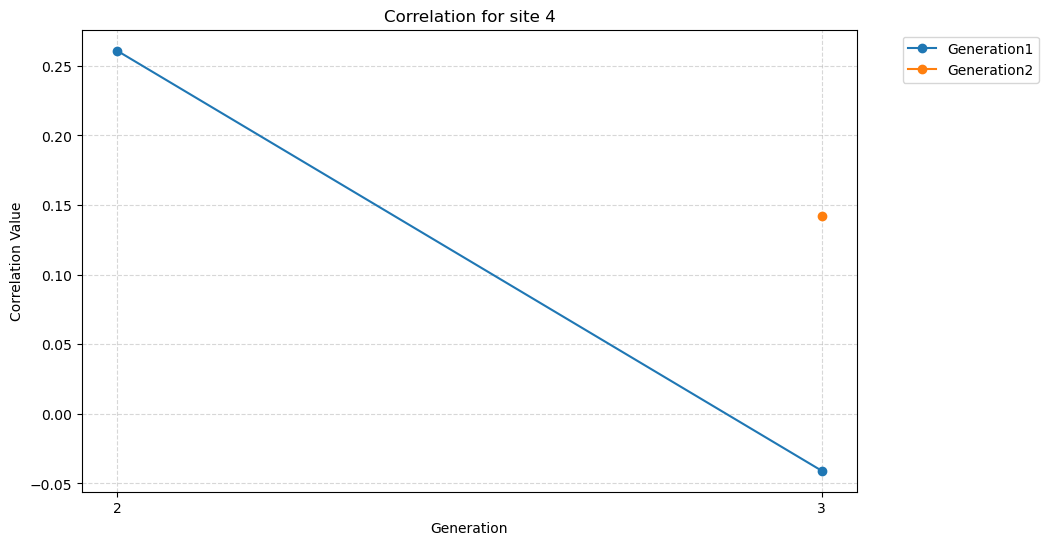

['1', '2', '3']
[['2', '3'], ['3']]
x-axis labels = ['2', '3']
x-axis labels = ['3']


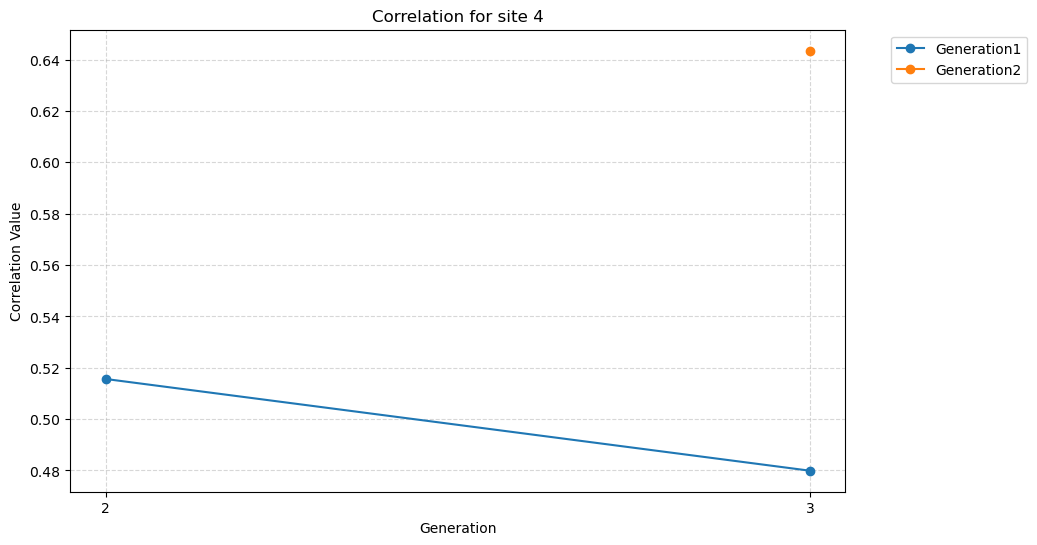

['1', '2', '3']
[['2', '3'], ['3']]
x-axis labels = ['2', '3']
x-axis labels = ['3']


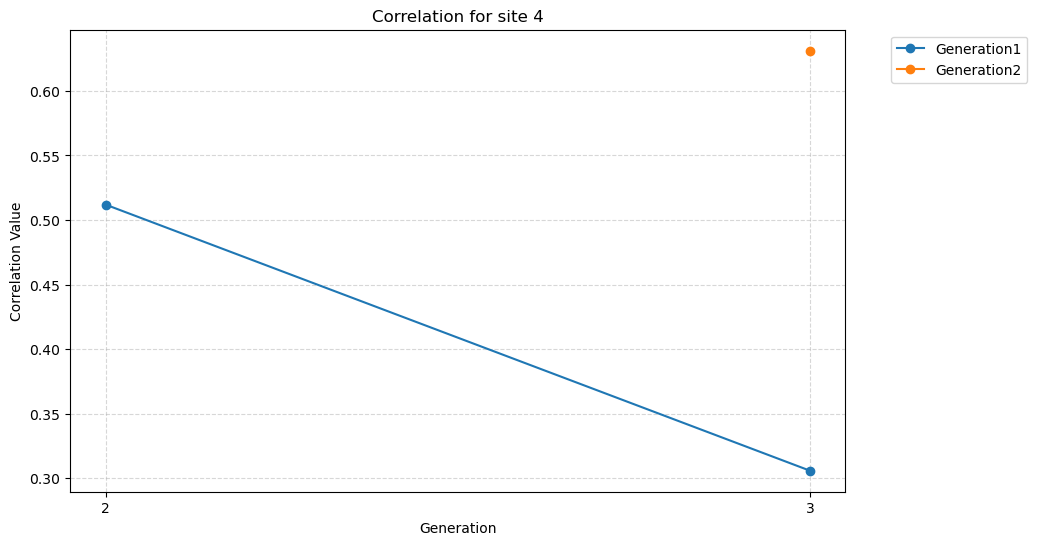

['1', '2', '3']
[['2', '3'], ['3']]
x-axis labels = ['2', '3']
x-axis labels = ['3']


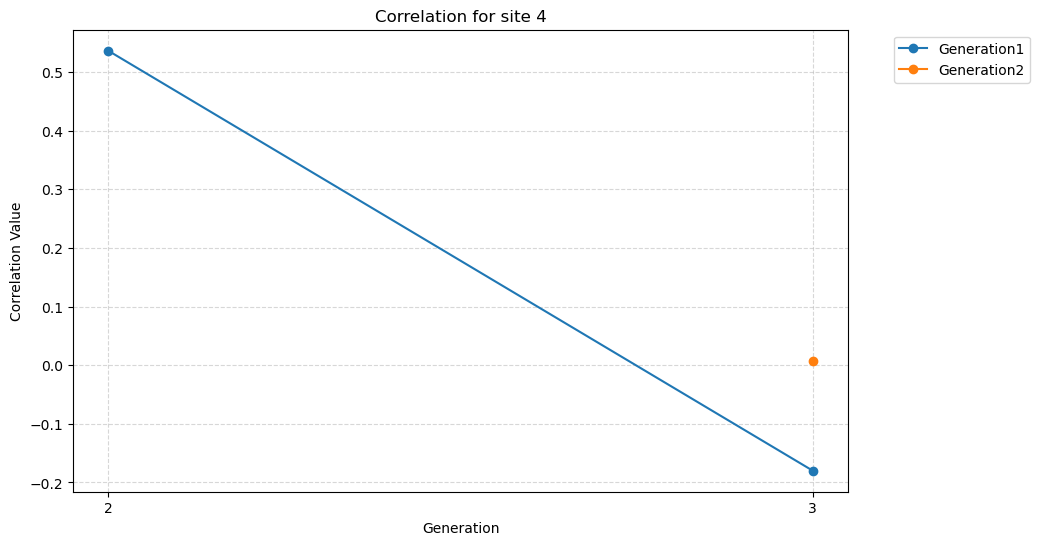

['1', '2', '3']
[['2', '3'], ['3']]
x-axis labels = ['2', '3']
x-axis labels = ['3']


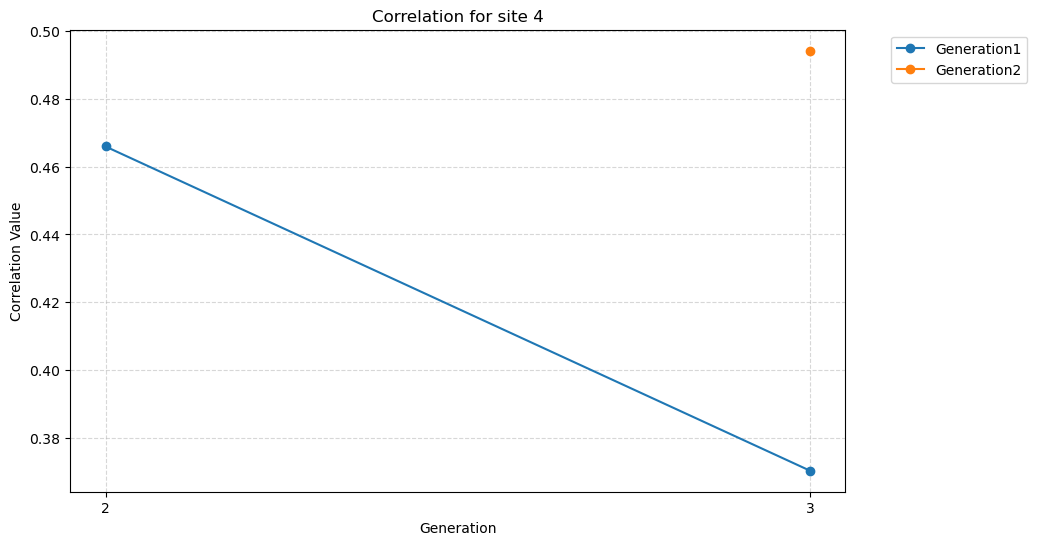

['1', '2', '3']
[['2', '3'], ['3']]
x-axis labels = ['2', '3']
x-axis labels = ['3']


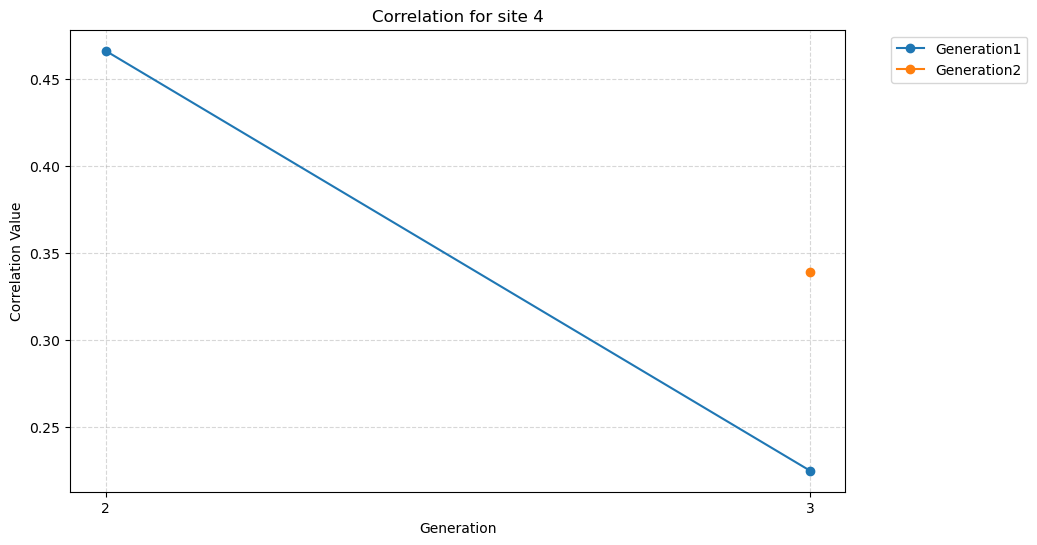

['1', '2', '3']
[['2', '3'], ['3']]
x-axis labels = ['2', '3']
x-axis labels = ['3']


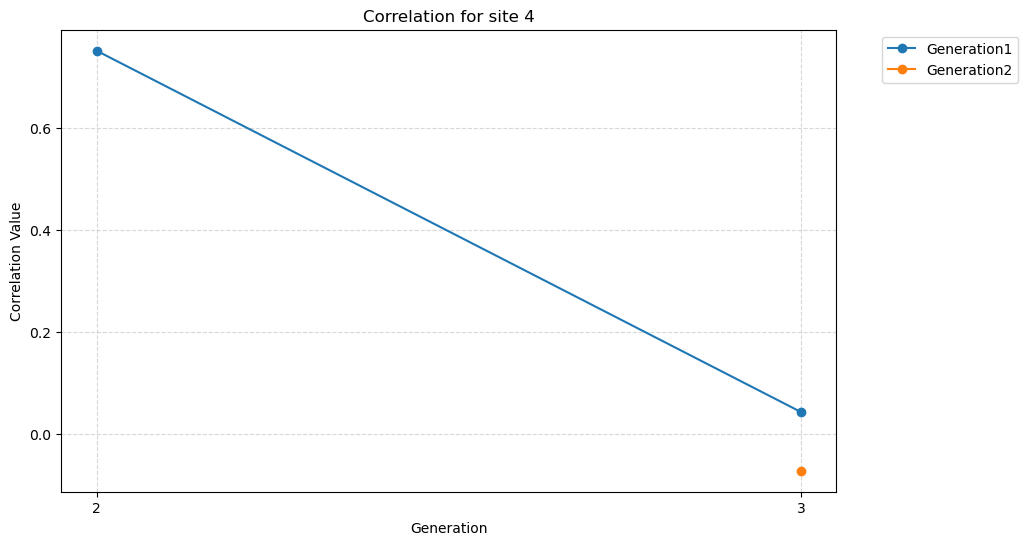

In [66]:
find_the_plots_for_the_site(master_df, '4')

In [59]:
covariance_to_correlation(delta_p_df(subset_dataframe(master_df, '2', '1')).cov())

,2_4_1
2_4_1,1.0


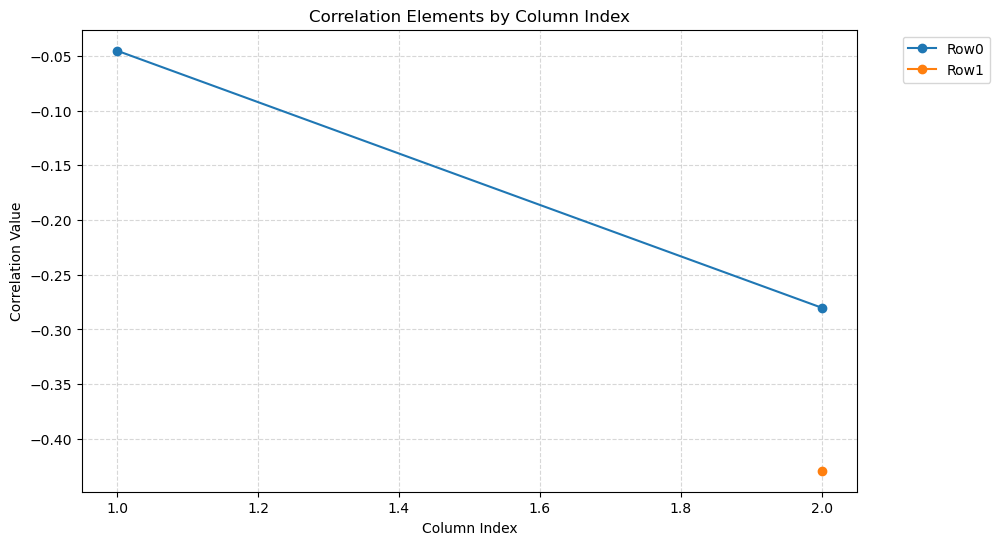

In [18]:
testing = plot_it(convert_to_matrix(covariance_to_correlation(delta_p_df(subset_dataframe(master_df, '1', '2')).cov())))

In [20]:
subset_site_cols(master_df, '1')

,1_0_1,1_1_1,1_1_2,1_1_3,1_1_4,1_1_5,1_1_6,1_1_7,1_1_8,1_1_9,...,1_4_7,1_4_6,1_4_5,1_4_4,1_4_3,1_4_2,1_4_1,1_4_11,1_4_10,1_4_12
0,0.037575,0.045527,0.017389,0.045850,0.052100,0.053384,0.049821,0.029935,0.118124,0.072380,...,0.052606,0.020712,0.024824,0.034030,0.037072,0.049188,0.020583,0.053019,0.070939,0.093858
1,0.264121,0.303972,0.241872,0.270096,0.261353,0.350732,0.298306,0.281586,0.271226,0.261311,...,0.242186,0.287795,0.484182,0.214930,0.354354,0.312868,0.476855,0.408450,0.261262,0.256796
2,0.010239,0.017308,0.006286,0.007417,0.006761,0.007185,0.004538,0.003671,0.008575,0.007824,...,0.001263,0.001296,0.001708,0.092487,0.001084,0.002199,0.001094,0.001256,0.001811,0.002489
3,0.020212,0.021860,0.053256,0.035844,0.036697,0.015677,0.025030,0.026685,0.024367,0.021652,...,0.014565,0.035421,0.008890,0.056410,0.007897,0.039981,0.010245,0.024736,0.020038,0.018529
4,0.067621,0.046952,0.068319,0.059664,0.069606,0.098633,0.071630,0.088640,0.069660,0.057809,...,0.173609,0.047538,0.059553,0.017524,0.018800,0.122327,0.043030,0.079852,0.147160,0.042673
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0.969326,0.983971,0.977568,0.968264,0.970782,0.989037,0.981445,0.978850,0.980933,0.984402,...,0.992646,0.986923,0.980001,0.992940,0.989744,0.990599,0.993421,0.983893,0.993481,0.977911
9996,0.159444,0.120164,0.152684,0.152257,0.111333,0.156217,0.154384,0.165332,0.158835,0.141228,...,0.126355,0.280653,0.124542,0.484123,0.224196,0.196468,0.224707,0.171476,0.199381,0.133409
9997,0.988558,0.994024,0.994880,0.996155,0.992441,0.983429,0.997036,0.994668,0.996630,0.970016,...,0.998568,0.998366,0.997615,0.999195,0.998658,0.995517,0.998993,0.997312,0.996977,0.995697
9998,0.973847,0.980444,0.976904,0.989949,0.966712,0.965471,0.975141,0.972510,0.967521,0.964271,...,0.962223,0.984378,0.930632,0.987690,0.942262,0.953583,0.976476,0.981718,0.989855,0.976161


In [21]:
array_the_reps(subset_site_cols(master_df, '1'))

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

In [25]:
subset_replicate(subset_site_cols(master_df, '1'), str(array_the_reps(subset_site_cols(master_df, '1'))[0]))

,1_0_1,1_1_1,1_2_1,1_3_1,1_4_1
0,0.037575,0.045527,0.027944,0.001647,0.020583
1,0.264121,0.303972,0.382195,0.746828,0.476855
2,0.010239,0.017308,0.004543,0.000312,0.001094
3,0.020212,0.021860,0.157563,0.125082,0.010245
4,0.067621,0.046952,0.037010,0.006074,0.043030
...,...,...,...,...,...
9995,0.969326,0.983971,0.989287,0.997638,0.993421
9996,0.159444,0.120164,0.285663,0.148178,0.224707
9997,0.988558,0.994024,0.997207,0.999656,0.998993
9998,0.973847,0.980444,0.988418,0.997309,0.976476


In [11]:
from itertools import combinations

# use a subsetted df for a site

def calculate_convergent_correlation(master_cov, generations, replicates):
    #initialize an empty matrix of size TxT (generations x generations)
    conv_corr_matrix = pd.DataFrame(0.0, index = [f'Gen_{g}' for g in generations], columns = [f'Gen_{g}' for g in generations])

    # get all unique pairs of replicates
    rep_pairs = list(combinations(replicates, 2))
    col_info = {c: c.split('_') for c in master_cov.columns}

    with np.errstate(all='ignore'):
        #loop through every cell (s, t)
        for s in generations:
            for t in generations:
                if s == t:
                    conv_corr_matrix.loc[f"Gen_{s}", f"Gen_{t}"] = 1.0
                    continue 
                    
                pair_correlations = []

                for rep_A, rep_B in rep_pairs:
                    cols_s_A = [c for c, p in col_info.items() if int(p[1]) == s and int(p[2]) == rep_A]
                    cols_t_B = [c for c, p in col_info.items() if int(p[1]) == t and int(p[2]) == rep_B]

                    cols_t_A = [c for c, p in col_info.items() if int(p[1]) == t and int(p[2]) == rep_A]
                    cols_s_B = [c for c, p in col_info.items() if int(p[1]) == s and int(p[2]) == rep_B]
                    
                    if not (cols_s_A and cols_t_B and cols_t_A and cols_s_B):
                        continue

                    cov_1 = master_cov.loc[cols_s_A, cols_t_B].values.mean()
                    var_s_A = master_cov.loc[cols_s_A, cols_s_A].values.mean()
                    var_t_B = master_cov.loc[cols_t_B, cols_t_B].values.mean()
                    geom_sd_1 = np.sqrt(var_s_A * var_t_B)

                    cov_2 = master_cov.loc[cols_s_B, cols_t_A].values.mean()
                    var_s_B = master_cov.loc[cols_s_B, cols_s_B].values.mean()
                    var_t_A = master_cov.loc[cols_t_A, cols_t_A].values.mean()
                    geom_sd_2 = np.sqrt(var_s_B * var_t_A)

                    if geom_sd_1 > 0 and geom_sd_2 > 0:
                        corr_1 = cov_1 / geom_sd_1
                        corr_2 = cov_2 / geom_sd_2
                        pair_correlations.append((corr_1 + corr_2) / 2.0)
                    
                 
                if pair_correlations:
                    conv_corr_matrix.loc[f"Gen_{s}", f"Gen_{t}"] = np.nanmean(pair_correlations)
                else:
                    conv_corr_matrix.loc[f"Gen_{s}", f"Gen_{t}"] = np.nan
    return conv_corr_matrix